# 1. Introduction

This notebook rebuilds the Adult Income baseline MLP experiment as the **before-deletion** reference for later machine-unlearning work.

It creates one fixed train/validation/test split, fits preprocessing on the training split only, and trains three baseline MLPs with seeds `42`, `43`, and `44`. The split and preprocessing are identical across seeds, so differences between the three models reflect model-training variation rather than data variation.

Notebook 1 does not define forget records and does not perform membership-inference evaluation. It saves per-record losses, true-class confidence values and predictions so Notebook 2 can evaluate later forget records against these original baseline models.


# 2. Imports and Reproducibility Configuration

All model hyperparameters are defined once and saved with each checkpoint. The classification threshold is fixed at `0.5` and is not tuned using the test set.


In [1]:
from pathlib import Path
import json
import random
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

PROJECT_ROOT = Path.cwd().parents[1]
RAW_DATA_PATH = PROJECT_ROOT / "data/raw/adult.csv"
PROCESSED_DIR = PROJECT_ROOT / "data/processed/adult/rebuilt"
MODEL_DIR = PROJECT_ROOT / "models/adult/rebuilt"
RESULTS_DIR = PROJECT_ROOT / "results/baseline/adult/rebuilt"
FIGURES_DIR = RESULTS_DIR / "figures"
TABLES_DIR = RESULTS_DIR / "tables"
METRICS_DIR = RESULTS_DIR / "metrics"

for directory in [PROCESSED_DIR, MODEL_DIR, RESULTS_DIR, FIGURES_DIR, TABLES_DIR, METRICS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

TRAINING_SEEDS = [42, 43, 44]
SPLIT_SEED = 42
CLASSIFICATION_THRESHOLD = 0.5
HIDDEN_LAYER_DIMS = (64, 32)
DROPOUT_PROBABILITY = 0.2
BATCH_SIZE = 256
LEARNING_RATE = 0.001
MAX_EPOCHS = 20
EARLY_STOPPING_PATIENCE = 3
EARLY_STOPPING_MIN_DELTA = 1e-4
PREPROCESSING_STRATEGY = "fixed_training_split_preprocessing"

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")
print(f"Project root: {PROJECT_ROOT}")


Using device: mps
Project root: /Users/niamhhughes/Desktop/Desktop - Niamh’s MacBook Pro/QUB/Research Proj/code


# 3. Load and Inspect Adult Income

The raw Adult Income CSV is loaded from the existing project data folder. The notebook validates the expected row and column count before cleaning.


In [2]:
adult_raw = pd.read_csv(RAW_DATA_PATH)

expected_shape = (48842, 15)
if adult_raw.shape != expected_shape:
    raise ValueError(f"Unexpected raw Adult shape {adult_raw.shape}; expected {expected_shape}.")

print(f"Loaded raw Adult Income data from: {RAW_DATA_PATH}")
print(f"Raw shape: {adult_raw.shape}")
display(adult_raw.head())
display(adult_raw["income"].value_counts().to_frame("count"))


Loaded raw Adult Income data from: /Users/niamhhughes/Desktop/Desktop - Niamh’s MacBook Pro/QUB/Research Proj/code/data/raw/adult.csv
Raw shape: (48842, 15)


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


,count
income,
<=50K,37155
>50K,11687


# 4. Data Cleaning and Target Creation

The existing validated cleaning approach is reused: string whitespace is stripped, `?` placeholders are replaced with `Unknown`, and the income label is converted to a binary target. The Census sampling weight `fnlwgt` is excluded from modelling, and the redundant categorical `education` column is excluded while retaining `educational-num`.


In [3]:
adult_clean = adult_raw.copy()
text_columns = adult_clean.select_dtypes(include=["object", "string"]).columns
for column in text_columns:
    adult_clean[column] = adult_clean[column].astype(str).str.strip()

adult_clean = adult_clean.replace("?", "Unknown")
adult_clean["income_binary"] = adult_clean["income"].map({"<=50K": 0, ">50K": 1})

if adult_clean["income_binary"].isna().any():
    raise ValueError("Target mapping created missing values.")

X = adult_clean.drop(columns=["income", "income_binary"])
y = adult_clean["income_binary"].astype(int)

numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "string"]).columns.tolist()
numerical_features = [feature for feature in numerical_features if feature != "fnlwgt"]
categorical_features = [feature for feature in categorical_features if feature != "education"]
model_input_columns = numerical_features + categorical_features
X = X[model_input_columns]

print(f"Cleaned shape including target: {adult_clean.shape}")
print(f"Modelling columns: {len(model_input_columns)}")
print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)
display(y.value_counts(normalize=True).rename("proportion").to_frame())


Cleaned shape including target: (48842, 16)
Modelling columns: 12
Numerical features: ['age', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical features: ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country']


,proportion
income_binary,
0,0.760718
1,0.239282


# 5. Fixed Train, Validation and Test Split

A single stratified 70%/15%/15% split is created and reused for all three baseline seeds. Original row indices are preserved because later forget sets must refer back to the original training records.


In [4]:
X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SPLIT_SEED,
    stratify=y,
)
X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp_raw,
    y_temp,
    test_size=0.50,
    random_state=SPLIT_SEED,
    stratify=y_temp,
)

split_validation = pd.DataFrame(
    [
        {"split": "train", "rows": len(X_train_raw), "positive_rate": y_train.mean()},
        {"split": "validation", "rows": len(X_val_raw), "positive_rate": y_val.mean()},
        {"split": "test", "rows": len(X_test_raw), "positive_rate": y_test.mean()},
    ]
)
all_split_indices = set(X_train_raw.index) | set(X_val_raw.index) | set(X_test_raw.index)
if len(all_split_indices) != len(adult_raw):
    raise ValueError("Split indices do not reconstruct the full dataset.")
if set(X_train_raw.index) & set(X_val_raw.index) or set(X_train_raw.index) & set(X_test_raw.index) or set(X_val_raw.index) & set(X_test_raw.index):
    raise ValueError("Train/validation/test splits overlap.")

display(split_validation)


,split,rows,positive_rate
0,train,34189,0.239287
1,validation,7326,0.239285
2,test,7327,0.239252


# 6. Fit and Validate Preprocessing

The scaler and one-hot encoder are fitted on the training split only. Validation and test records are transformed using the training-fitted preprocessing objects.


In [5]:
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numerical_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)
preprocessor.fit(X_train_raw)

processed_feature_names = preprocessor.get_feature_names_out().tolist()

def transform_features(raw_features):
    processed = preprocessor.transform(raw_features)
    return pd.DataFrame(processed, columns=processed_feature_names, index=raw_features.index)

X_train_processed = transform_features(X_train_raw)
X_val_processed = transform_features(X_val_raw)
X_test_processed = transform_features(X_test_raw)

if X_train_processed.shape[1] != len(processed_feature_names):
    raise ValueError("Processed feature-name count does not match matrix width.")
if list(X_train_processed.columns) != processed_feature_names:
    raise ValueError("Processed column ordering mismatch.")

print(f"Processed feature count: {len(processed_feature_names)}")
print(f"Processed train/validation/test shapes: {X_train_processed.shape}, {X_val_processed.shape}, {X_test_processed.shape}")


Processed feature count: 91
Processed train/validation/test shapes: (34189, 91), (7326, 91), (7327, 91)


# 7. Define the Baseline MLP

The MLP architecture matches the validated Adult Income baseline: two hidden layers with ReLU activations and dropout.


In [6]:
class AdultIncomeMLP(nn.Module):
    """Small MLP for binary Adult Income classification."""

    def __init__(self, input_dim, hidden_layer_dims=HIDDEN_LAYER_DIMS, dropout_probability=DROPOUT_PROBABILITY):
        super().__init__()
        hidden_1, hidden_2 = hidden_layer_dims
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_1),
            nn.ReLU(),
            nn.Dropout(dropout_probability),
            nn.Linear(hidden_1, hidden_2),
            nn.ReLU(),
            nn.Dropout(dropout_probability),
            nn.Linear(hidden_2, 1),
        )

    def forward(self, features):
        return self.network(features)

input_dim = X_train_processed.shape[1]
print(f"Input dimension: {input_dim}")
print(AdultIncomeMLP(input_dim))


Input dimension: 91
AdultIncomeMLP(
  (network): Sequential(
    (0): Linear(in_features=91, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


# 8. Training and Early-Stopping Functions

Each seed starts from a fresh model initialisation. The training `DataLoader` uses a seeded generator so mini-batch ordering is reproducible after a clean restart.


In [7]:
def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def make_dataset(features, labels):
    return TensorDataset(
        torch.tensor(features.values, dtype=torch.float32),
        torch.tensor(labels.values, dtype=torch.float32).view(-1, 1),
    )


def make_loader(dataset, batch_size=BATCH_SIZE, shuffle=False, seed=None):
    generator = None
    if shuffle:
        generator = torch.Generator()
        generator.manual_seed(seed)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, generator=generator)


def average_loss(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for features, labels in loader:
            features = features.to(device)
            labels = labels.to(device)
            logits = model(features)
            loss = criterion(logits, labels)
            total_loss += loss.item() * features.size(0)
    return total_loss / len(loader.dataset)


def train_one_seed(seed):
    set_all_seeds(seed)
    model = AdultIncomeMLP(input_dim).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

    train_loader = make_loader(make_dataset(X_train_processed, y_train), shuffle=True, seed=seed)
    val_loader = make_loader(make_dataset(X_val_processed, y_val), shuffle=False)

    best_val_loss = float("inf")
    best_epoch = 0
    best_state = None
    epochs_without_improvement = 0
    history_rows = []
    start_time = time.perf_counter()
    early_stopping_triggered = False

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        train_loss_sum = 0.0
        for features, labels in train_loader:
            features = features.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            logits = model(features)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            train_loss_sum += loss.item() * features.size(0)

        train_loss = train_loss_sum / len(train_loader.dataset)
        val_loss = average_loss(model, val_loader, criterion)
        history_rows.append({"seed": seed, "epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})

        if val_loss < best_val_loss - EARLY_STOPPING_MIN_DELTA:
            best_val_loss = val_loss
            best_epoch = epoch
            epochs_without_improvement = 0
            best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            early_stopping_triggered = True
            break

    runtime_seconds = time.perf_counter() - start_time
    if best_state is None:
        raise RuntimeError(f"No best checkpoint captured for seed {seed}.")
    model.load_state_dict({key: value.to(device) for key, value in best_state.items()})
    history = pd.DataFrame(history_rows)
    training_summary = {
        "seed": seed,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "epochs_run": len(history),
        "runtime_seconds": runtime_seconds,
        "early_stopping_triggered": early_stopping_triggered,
    }
    return model, history, training_summary


def predict_records(model, features, labels, split_name, seed):
    dataset = make_dataset(features, labels)
    loader = make_loader(dataset, shuffle=False)
    criterion = nn.BCEWithLogitsLoss(reduction="none")
    rows = []
    model.eval()
    position = 0
    with torch.no_grad():
        for batch_features, batch_labels in loader:
            batch_size = batch_features.size(0)
            batch_features = batch_features.to(device)
            batch_labels_device = batch_labels.to(device)
            logits = model(batch_features)
            probabilities = torch.sigmoid(logits)
            losses = criterion(logits, batch_labels_device)
            batch_true = batch_labels.numpy().ravel().astype(int)
            batch_prob = probabilities.cpu().numpy().ravel()
            batch_loss = losses.cpu().numpy().ravel()
            batch_indices = features.index[position:position + batch_size]
            for original_index, true_label, probability, loss in zip(batch_indices, batch_true, batch_prob, batch_loss):
                predicted_label = int(probability >= CLASSIFICATION_THRESHOLD)
                true_class_confidence = probability if true_label == 1 else 1 - probability
                rows.append(
                    {
                        "original_index": int(original_index),
                        "dataset_split": split_name,
                        "seed": seed,
                        "y_true": int(true_label),
                        "y_pred": predicted_label,
                        "y_probability": float(probability),
                        "per_record_loss": float(loss),
                        "negative_loss": float(-loss),
                        "true_class_confidence": float(true_class_confidence),
                        "correct_prediction": int(predicted_label == true_label),
                    }
                )
            position += batch_size
    return pd.DataFrame(rows)


# 9. Train Three Baseline MLPs

Three original baseline models are trained on the same fixed training set using seeds `42`, `43`, and `44`.


In [8]:
baseline_models = {}
training_histories = []
training_summaries = []
record_outputs = []

for seed in TRAINING_SEEDS:
    model, history, summary = train_one_seed(seed)
    baseline_models[seed] = model
    training_histories.append(history)
    training_summaries.append(summary)
    print(
        f"Seed {seed}: best_epoch={summary['best_epoch']}, "
        f"best_val_loss={summary['best_val_loss']:.4f}, "
        f"epochs_run={summary['epochs_run']}, runtime={summary['runtime_seconds']:.2f}s"
    )
    for split_name, features, labels in [
        ("train", X_train_processed, y_train),
        ("validation", X_val_processed, y_val),
        ("test", X_test_processed, y_test),
    ]:
        record_outputs.append(predict_records(model, features, labels, split_name, seed))

baseline_training_histories = pd.concat(training_histories, ignore_index=True)
baseline_training_summary = pd.DataFrame(training_summaries)
baseline_record_outputs = pd.concat(record_outputs, ignore_index=True)

display(baseline_training_summary)


Seed 42: best_epoch=10, best_val_loss=0.3010, epochs_run=13, runtime=7.97s


Seed 43: best_epoch=9, best_val_loss=0.3012, epochs_run=12, runtime=6.79s


Seed 44: best_epoch=13, best_val_loss=0.3007, epochs_run=16, runtime=9.03s


,seed,best_epoch,best_val_loss,epochs_run,runtime_seconds,early_stopping_triggered
0,42,10,0.301041,13,7.970389,True
1,43,9,0.301194,12,6.786671,True
2,44,13,0.300721,16,9.031219,True


# 10. Main Predictive Results

Predictive utility is evaluated once on the untouched test set for each seed. Predictive AUROC refers to income classification ranking, not membership-inference attack AUROC.


In [9]:
metric_rows = []
classification_report_rows = []
confusion_rows = []
roc_rows = []

for seed in TRAINING_SEEDS:
    test_records = baseline_record_outputs[
        (baseline_record_outputs["seed"] == seed)
        & (baseline_record_outputs["dataset_split"] == "test")
    ]
    y_true = test_records["y_true"].to_numpy()
    y_pred = test_records["y_pred"].to_numpy()
    y_prob = test_records["y_probability"].to_numpy()

    metric_rows.append(
        {
            "seed": seed,
            "accuracy": accuracy_score(y_true, y_pred),
            "positive_class_precision": precision_score(y_true, y_pred, zero_division=0),
            "positive_class_recall": recall_score(y_true, y_pred, zero_division=0),
            "f1_score": f1_score(y_true, y_pred),
            "predictive_auroc": roc_auc_score(y_true, y_prob),
            "test_loss": test_records["per_record_loss"].mean(),
        }
    )

    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    for label, values in report.items():
        row = {"seed": seed, "label": label}
        if isinstance(values, dict):
            row.update(values)
        else:
            row["f1-score"] = values
        classification_report_rows.append(row)

    matrix = confusion_matrix(y_true, y_pred)
    confusion_rows.append(
        {
            "seed": seed,
            "true_<=50K_pred_<=50K": int(matrix[0, 0]),
            "true_<=50K_pred_>50K": int(matrix[0, 1]),
            "true_>50K_pred_<=50K": int(matrix[1, 0]),
            "true_>50K_pred_>50K": int(matrix[1, 1]),
        }
    )

    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    for fpr_value, tpr_value, threshold in zip(fpr, tpr, thresholds):
        roc_rows.append({"seed": seed, "false_positive_rate": fpr_value, "true_positive_rate": tpr_value, "threshold": threshold})

baseline_metrics_by_seed = pd.DataFrame(metric_rows)
baseline_classification_reports = pd.DataFrame(classification_report_rows)
baseline_confusion_matrices = pd.DataFrame(confusion_rows)
baseline_roc_curves = pd.DataFrame(roc_rows)

display(baseline_metrics_by_seed)


,seed,accuracy,positive_class_precision,positive_class_recall,f1_score,predictive_auroc,test_loss
0,42,0.856012,0.733601,0.625214,0.675085,0.909657,0.312553
1,43,0.857650,0.759883,0.592128,0.665598,0.910031,0.311535
2,44,0.858742,0.752817,0.609812,0.673810,0.910135,0.311865


# 11. Per-Seed Results and Training Stability

The aggregate table summarises variation across the three training seeds. Three seeds help separate model-training variation from later deletion effects.


,metric,mean,std,mean_plus_minus_std
0,accuracy,0.857468,0.001374,0.8575 ± 0.0014
1,positive_class_precision,0.748767,0.013601,0.7488 ± 0.0136
2,positive_class_recall,0.609051,0.016556,0.6091 ± 0.0166
3,f1_score,0.671498,0.005149,0.6715 ± 0.0051
4,predictive_auroc,0.909941,0.000252,0.9099 ± 0.0003
5,test_loss,0.311984,0.000520,0.3120 ± 0.0005


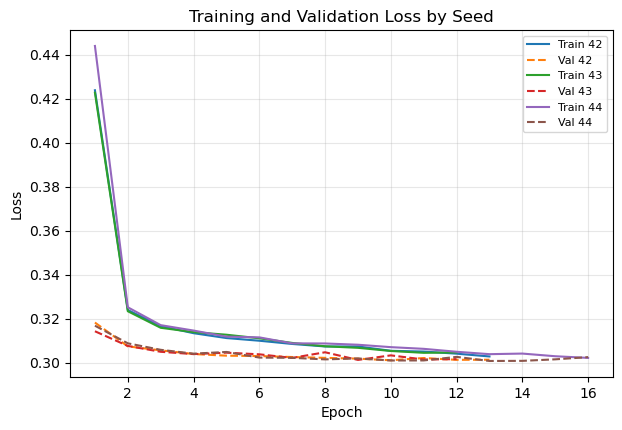

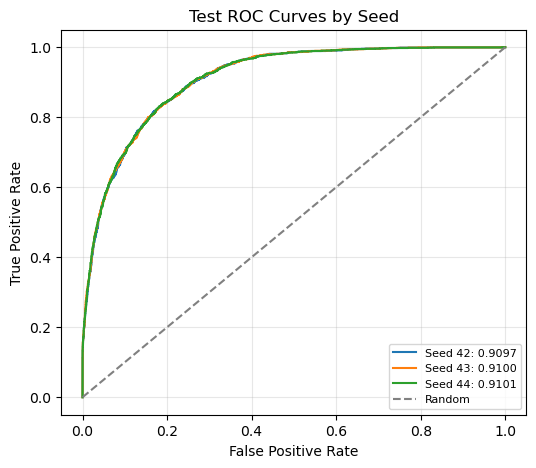

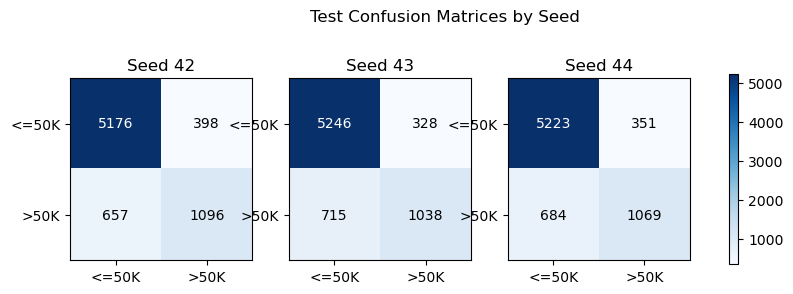

In [10]:
aggregate_rows = []
for metric in ["accuracy", "positive_class_precision", "positive_class_recall", "f1_score", "predictive_auroc", "test_loss"]:
    aggregate_rows.append(
        {
            "metric": metric,
            "mean": baseline_metrics_by_seed[metric].mean(),
            "std": baseline_metrics_by_seed[metric].std(ddof=1),
            "mean_plus_minus_std": f"{baseline_metrics_by_seed[metric].mean():.4f} ± {baseline_metrics_by_seed[metric].std(ddof=1):.4f}",
        }
    )
baseline_metrics_aggregate = pd.DataFrame(aggregate_rows)
display(baseline_metrics_aggregate)

loss_fig, loss_ax = plt.subplots(figsize=(7, 4.5))
for seed, seed_history in baseline_training_histories.groupby("seed"):
    loss_ax.plot(seed_history["epoch"], seed_history["train_loss"], linestyle="-", label=f"Train {seed}")
    loss_ax.plot(seed_history["epoch"], seed_history["val_loss"], linestyle="--", label=f"Val {seed}")
loss_ax.set_xlabel("Epoch")
loss_ax.set_ylabel("Loss")
loss_ax.set_title("Training and Validation Loss by Seed")
loss_ax.legend(fontsize=8)
loss_ax.grid(True, alpha=0.3)
plt.show()

roc_fig, roc_ax = plt.subplots(figsize=(6, 5))
for seed in TRAINING_SEEDS:
    seed_roc = baseline_roc_curves[baseline_roc_curves["seed"] == seed]
    seed_auc = baseline_metrics_by_seed.loc[baseline_metrics_by_seed["seed"] == seed, "predictive_auroc"].iloc[0]
    roc_ax.plot(seed_roc["false_positive_rate"], seed_roc["true_positive_rate"], label=f"Seed {seed}: {seed_auc:.4f}")
roc_ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
roc_ax.set_xlabel("False Positive Rate")
roc_ax.set_ylabel("True Positive Rate")
roc_ax.set_title("Test ROC Curves by Seed")
roc_ax.legend(fontsize=8)
roc_ax.grid(True, alpha=0.3)
plt.show()

confusion_fig, axes = plt.subplots(1, 3, figsize=(10, 3.3))
for ax, seed in zip(axes, TRAINING_SEEDS):
    row = baseline_confusion_matrices[baseline_confusion_matrices["seed"] == seed].iloc[0]
    matrix = np.array([[row["true_<=50K_pred_<=50K"], row["true_<=50K_pred_>50K"]], [row["true_>50K_pred_<=50K"], row["true_>50K_pred_>50K"]]])
    image = ax.imshow(matrix, cmap="Blues")
    ax.set_title(f"Seed {seed}")
    ax.set_xticks([0, 1], ["<=50K", ">50K"])
    ax.set_yticks([0, 1], ["<=50K", ">50K"])
    threshold = matrix.max() / 2
    for r in range(2):
        for c in range(2):
            ax.text(c, r, int(matrix[r, c]), ha="center", va="center", color="white" if matrix[r, c] > threshold else "black")
confusion_fig.colorbar(image, ax=axes.ravel().tolist(), shrink=0.75)
confusion_fig.suptitle("Test Confusion Matrices by Seed")
plt.show()


# 12. Save Models, Predictions and Metadata

All artifacts are saved under rebuilt output folders so existing notebooks remain untouched.


In [11]:
# Save data and preprocessing.
adult_clean.drop(columns=["income_binary"]).to_csv(PROCESSED_DIR / "adult_clean.csv", index=False)
X_train_raw.to_csv(PROCESSED_DIR / "X_train_raw.csv", index=True)
X_val_raw.to_csv(PROCESSED_DIR / "X_val_raw.csv", index=True)
X_test_raw.to_csv(PROCESSED_DIR / "X_test_raw.csv", index=True)
y_train.to_csv(PROCESSED_DIR / "y_train.csv", index=True)
y_val.to_csv(PROCESSED_DIR / "y_val.csv", index=True)
y_test.to_csv(PROCESSED_DIR / "y_test.csv", index=True)
X_train_processed.to_csv(PROCESSED_DIR / "X_train_processed.csv", index=True)
X_val_processed.to_csv(PROCESSED_DIR / "X_val_processed.csv", index=True)
X_test_processed.to_csv(PROCESSED_DIR / "X_test_processed.csv", index=True)
joblib.dump(preprocessor, MODEL_DIR / "adult_preprocessor.joblib")

feature_names = pd.DataFrame({"processed_feature_name": processed_feature_names})
feature_names.to_csv(TABLES_DIR / "processed_feature_names.csv", index=False)

# Save models.
for seed, model in baseline_models.items():
    summary = baseline_training_summary[baseline_training_summary["seed"] == seed].iloc[0].to_dict()
    checkpoint = {
        "seed": seed,
        "model_state_dict": {key: value.detach().cpu().clone() for key, value in model.state_dict().items()},
        "architecture": "AdultIncomeMLP",
        "hidden_layer_dims": HIDDEN_LAYER_DIMS,
        "dropout_probability": DROPOUT_PROBABILITY,
        "learning_rate": LEARNING_RATE,
        "batch_size": BATCH_SIZE,
        "max_epochs": MAX_EPOCHS,
        "early_stopping_patience": EARLY_STOPPING_PATIENCE,
        "early_stopping_min_delta": EARLY_STOPPING_MIN_DELTA,
        "classification_threshold": CLASSIFICATION_THRESHOLD,
        "processed_feature_names": processed_feature_names,
        "input_dim": input_dim,
        "best_epoch": int(summary["best_epoch"]),
        "best_val_loss": float(summary["best_val_loss"]),
        "epochs_run": int(summary["epochs_run"]),
        "runtime_seconds": float(summary["runtime_seconds"]),
        "preprocessing_strategy": PREPROCESSING_STRATEGY,
    }
    torch.save(checkpoint, MODEL_DIR / f"adult_baseline_seed_{seed}.pt")

# Save tables.
baseline_metrics_by_seed.to_csv(METRICS_DIR / "baseline_metrics_by_seed.csv", index=False)
baseline_metrics_aggregate.to_csv(METRICS_DIR / "baseline_metrics_aggregate.csv", index=False)
baseline_classification_reports.to_csv(METRICS_DIR / "baseline_classification_reports.csv", index=False)
baseline_confusion_matrices.to_csv(METRICS_DIR / "baseline_confusion_matrices.csv", index=False)
baseline_record_outputs.to_csv(TABLES_DIR / "baseline_record_outputs.csv", index=False)
baseline_training_histories.to_csv(TABLES_DIR / "baseline_training_histories.csv", index=False)
baseline_training_summary.to_csv(METRICS_DIR / "baseline_training_summary.csv", index=False)
baseline_roc_curves.to_csv(TABLES_DIR / "baseline_roc_curves.csv", index=False)
split_validation.to_csv(TABLES_DIR / "split_validation.csv", index=False)

# Save figures.
loss_fig.savefig(FIGURES_DIR / "baseline_loss_curves_by_seed.png", dpi=300, bbox_inches="tight")
roc_fig.savefig(FIGURES_DIR / "baseline_roc_curves_by_seed.png", dpi=300, bbox_inches="tight")
confusion_fig.savefig(FIGURES_DIR / "baseline_confusion_matrices_by_seed.png", dpi=300, bbox_inches="tight")

# Manifest with project-relative paths.
def rel(path):
    return str(Path(path).resolve().relative_to(PROJECT_ROOT.resolve()))

manifest_rows = []
for seed in TRAINING_SEEDS:
    manifest_rows.append({"artifact": f"baseline_checkpoint_seed_{seed}", "path": rel(MODEL_DIR / f"adult_baseline_seed_{seed}.pt")})
for artifact_name, path in [
    ("preprocessor", MODEL_DIR / "adult_preprocessor.joblib"),
    ("metrics_by_seed", METRICS_DIR / "baseline_metrics_by_seed.csv"),
    ("metrics_aggregate", METRICS_DIR / "baseline_metrics_aggregate.csv"),
    ("record_outputs", TABLES_DIR / "baseline_record_outputs.csv"),
    ("training_histories", TABLES_DIR / "baseline_training_histories.csv"),
    ("processed_train", PROCESSED_DIR / "X_train_processed.csv"),
    ("processed_validation", PROCESSED_DIR / "X_val_processed.csv"),
    ("processed_test", PROCESSED_DIR / "X_test_processed.csv"),
]:
    manifest_rows.append({"artifact": artifact_name, "path": rel(path)})

baseline_artifact_manifest = pd.DataFrame(manifest_rows)
baseline_artifact_manifest["exists"] = baseline_artifact_manifest["path"].map(lambda path: (PROJECT_ROOT / path).exists())
if not baseline_artifact_manifest["exists"].all():
    raise ValueError("At least one baseline artifact was not saved correctly.")
baseline_artifact_manifest.to_csv(TABLES_DIR / "baseline_artifact_manifest.csv", index=False)

display(baseline_artifact_manifest)


,artifact,path,exists
0,baseline_checkpoint_seed_42,models/adult/rebuilt/adult_baseline_seed_42.pt,True
1,baseline_checkpoint_seed_43,models/adult/rebuilt/adult_baseline_seed_43.pt,True
2,baseline_checkpoint_seed_44,models/adult/rebuilt/adult_baseline_seed_44.pt,True
3,preprocessor,models/adult/rebuilt/adult_preprocessor.joblib,True
4,metrics_by_seed,results/baseline/adult/rebuilt/metrics/baselin...,True
5,metrics_aggregate,results/baseline/adult/rebuilt/metrics/baselin...,True
6,record_outputs,results/baseline/adult/rebuilt/tables/baseline...,True
7,training_histories,results/baseline/adult/rebuilt/tables/baseline...,True
8,processed_train,data/processed/adult/rebuilt/X_train_processed...,True
9,processed_validation,data/processed/adult/rebuilt/X_val_processed.csv,True


# 13. Final Findings

The rebuilt baseline experiment trained three original MLPs on the same fixed training split. The aggregate metrics above show how stable predictive utility is across model seeds. Predictive AUROC measures income-class ranking performance and is distinct from later MIA attack AUROC.

Notebook 1 establishes the original before-deletion reference. Forget sets are intentionally not created here; Notebook 2 will define deletion scenarios and compare full-retraining references against these saved baseline models.
